In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from joblib import Parallel, delayed
from scipy.ndimage import uniform_filter
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from tqdm import tqdm
from xgboost import XGBClassifier

ROOT = Path('.')
DATA_DIR = ROOT / 'data'
RANDOM_STATE = 42
TRAIN_CAP_PER_CLASS = 150_000

CLASS_NAMES = {
    0: 'Unknown',
    1: 'Greenery',
    2: 'Sand',
    3: 'Water',
    4: 'Cement',
}

LABEL_TO_XGB = {1: 0, 2: 1, 3: 2, 4: 3}
XGB_TO_LABEL = {v: k for k, v in LABEL_TO_XGB.items()}


In [ ]:
def extract_sample_id(path):
    match = re.search(r'(\d+)', Path(path).stem)
    if not match:
        raise ValueError(f'Could not extract numeric id from {path}')
    return match.group(1)


def build_pairs_dataframe(data_dir):
    img_paths = {extract_sample_id(p): p for p in (data_dir / 'imgs').glob('*.tif')}
    mask_paths = {extract_sample_id(p): p for p in (data_dir / 'masks').glob('*.tif')}

    if set(img_paths) != set(mask_paths):
        missing_imgs = sorted(set(mask_paths) - set(img_paths))
        missing_masks = sorted(set(img_paths) - set(mask_paths))
        raise ValueError(f'Unpaired files found. missing_imgs={missing_imgs[:5]} missing_masks={missing_masks[:5]}')

    rows = []
    for sample_id in sorted(img_paths, key=int):
        rows.append(
            {
                'sample_id': sample_id,
                'img_path': str(img_paths[sample_id]),
                'mask_path': str(mask_paths[sample_id]),
            }
        )

    return pd.DataFrame(rows)


def mask_summary(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    values, counts = np.unique(mask, return_counts=True)
    summary = {int(v): int(c) for v, c in zip(values, counts)}
    total = int(mask.size)

    return {
        'total_pixels': total,
        'has_water': int(3 in summary),
        'has_cement': int(4 in summary),
        'has_sand': int(2 in summary),
        **{f'count_{cls}': summary.get(cls, 0) for cls in range(5)},
    }


def build_metadata(data_dir):
    pairs = build_pairs_dataframe(data_dir)
    summaries = [mask_summary(path) for path in tqdm(pairs['mask_path'], desc='Scanning masks')]
    meta = pd.concat([pairs, pd.DataFrame(summaries)], axis=1)
    return meta


def build_strata(df):
    strata = np.where(
        (df['has_water'] == 1) & (df['has_cement'] == 1),
        'water_and_cement',
        np.where(
            df['has_water'] == 1,
            'water_only',
            np.where(df['has_cement'] == 1, 'cement_only', 'base')
        ),
    )

    strata = pd.Series(strata, index=df.index)
    counts = strata.value_counts()
    strata = strata.where(strata.map(counts) >= 2, 'base')
    return strata


def split_metadata(meta, random_state=RANDOM_STATE):
    meta = meta.copy()
    meta['stratum'] = build_strata(meta)

    train_df, temp_df = train_test_split(
        meta,
        test_size=0.30,
        random_state=random_state,
        stratify=meta['stratum'],
    )

    temp_df = temp_df.copy()
    temp_df['stratum'] = build_strata(temp_df)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=random_state,
        stratify=temp_df['stratum'],
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def print_split_summary(name, df):
    print(f'[{name}] images: {len(df)}')
    for cls in range(5):
        pixels = int(df[f'count_{cls}'].sum())
        images = int((df[f'count_{cls}'] > 0).sum())
        print(f"  {CLASS_NAMES[cls]:<8} pixels={pixels:>9,} images={images:>3}")
    print('  strata:', df['stratum'].value_counts().to_dict())

def plot_class_distribution(y, title):
    classes, counts = np.unique(y, return_counts=True)
    labels = [f"{int(cls)} - {CLASS_NAMES.get(int(cls), f'Class {int(cls)}')}" for cls in classes]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(
        labels,
        counts,
        color=["#4CAF50", "#D2B48C", "#1E88E5", "#9E9E9E"][: len(labels)],
    )
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Pixel count")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            count,
            f"{int(count):,}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()


meta = build_metadata(DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)


Scanning masks: 100%|██████████| 365/365 [00:00<00:00, 761.15it/s]

[train] images: 255
  Unknown  pixels=6,418,803 images=252
  Greenery pixels=7,291,914 images=214
  Sand     pixels=2,718,506 images= 76
  Water    pixels=  142,236 images= 18
  Cement   pixels=  140,221 images= 64
  strata: {'base': 178, 'cement_only': 59, 'water_only': 13, 'water_and_cement': 5}
[val] images: 55
  Unknown  pixels=1,481,283 images= 53
  Greenery pixels=1,276,183 images= 44
  Sand     pixels=  691,387 images= 20
  Water    pixels=   89,897 images=  4
  Cement   pixels=   65,730 images= 14
  strata: {'base': 38, 'cement_only': 13, 'water_only': 3, 'water_and_cement': 1}
[test] images: 55
  Unknown  pixels=1,421,382 images= 55
  Greenery pixels=1,749,576 images= 49
  Sand     pixels=  377,985 images= 13
  Water    pixels=   15,210 images=  4
  Cement   pixels=   40,327 images= 14
  strata: {'base': 38, 'cement_only': 13, 'water_only': 3, 'water_and_cement': 1}


In [3]:
def local_mean_std(x, size=3):
    mean = uniform_filter(x, size=size, mode='reflect')
    mean_sq = uniform_filter(x * x, size=size, mode='reflect')
    var = np.maximum(mean_sq - mean * mean, 0.0)
    return mean, np.sqrt(var)


def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)


def preprocess_img(img_path, mask_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    img = np.clip(img, 0, 10000) / 10000.0
    return img, mask


def extract_features(img):
    b = img.astype(np.float32)

    blue = b[1]
    green = b[2]
    red = b[3]
    nir = b[7]
    swir1 = b[10]
    swir2 = b[11]

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)

    red_mean, red_std = local_mean_std(red, size=3)
    nir_mean, nir_std = local_mean_std(nir, size=3)
    swir1_mean, swir1_std = local_mean_std(swir1, size=3)
    swir2_mean, swir2_std = local_mean_std(swir2, size=3)

    features = np.concatenate(
        [
            b,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            bsi[np.newaxis, ...],
            red_mean[np.newaxis, ...],
            red_std[np.newaxis, ...],
            nir_mean[np.newaxis, ...],
            nir_std[np.newaxis, ...],
            swir1_mean[np.newaxis, ...],
            swir1_std[np.newaxis, ...],
            swir2_mean[np.newaxis, ...],
            swir2_std[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f'B{i + 1}' for i in range(b.shape[0])] + [
        'ndvi',
        'ndwi',
        'mndwi',
        'ndbi',
        'bsi',
        'red_mean_3',
        'red_std_3',
        'nir_mean_3',
        'nir_std_3',
        'swir1_mean_3',
        'swir1_std_3',
        'swir2_mean_3',
        'swir2_std_3',
    ]

    return features, feature_names


def process_pair(img_path, mask_path):
    img, mask = preprocess_img(img_path, mask_path)
    features, feature_names = extract_features(img)

    valid = (mask != 0) & (~np.all(img[:12] <= 1e-8, axis=0))
    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)

    return X, y, feature_names


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    feature_names = None

    for X, y, names in results:
        X_parts.append(X)
        y_parts.append(y)
        if feature_names is None:
            feature_names = names

    X_all = np.concatenate(X_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    return X_all, y_all, feature_names


In [4]:
def count_by_class(y):
    values, counts = np.unique(y, return_counts=True)
    return {CLASS_NAMES[int(v)]: int(c) for v, c in zip(values, counts)}


def sample_training_pixels(X, y, cap_per_class=TRAIN_CAP_PER_CLASS, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    chosen = []

    for cls in [1, 2, 3, 4]:
        cls_idx = np.where(y == cls)[0]
        take = min(cap_per_class, len(cls_idx))
        selected = rng.choice(cls_idx, size=take, replace=False)
        chosen.append(selected)
        print(f'{CLASS_NAMES[cls]:<8} available={len(cls_idx):>9,} sampled={take:>9,}')

    chosen = np.concatenate(chosen)
    rng.shuffle(chosen)
    return X[chosen], y[chosen]


def encode_labels(y):
    return np.array([LABEL_TO_XGB[int(v)] for v in y], dtype=np.uint8)


def decode_labels(y):
    return np.array([XGB_TO_LABEL[int(v)] for v in y], dtype=np.uint8)


def evaluate_split(name, model, X, y):
    y_pred = decode_labels(model.predict(X))
    print(f'===== {name} =====')
    print(classification_report(y, y_pred, digits=4, labels=[1, 2, 3, 4]))
    cm = confusion_matrix(y, y_pred, labels=[1, 2, 3, 4])
    print('Confusion Matrix:\n', cm)

    macro_iou = jaccard_score(y, y_pred, average='macro', labels=[1, 2, 3, 4])
    per_class_iou = jaccard_score(y, y_pred, average=None, labels=[1, 2, 3, 4])
    print('mIoU:', macro_iou)
    print('Per-class IoU:', {CLASS_NAMES[cls]: float(score) for cls, score in zip([1, 2, 3, 4], per_class_iou)})

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(4), [CLASS_NAMES[c] for c in [1, 2, 3, 4]], rotation=45, ha='right')
    ax.set_yticks(range(4), [CLASS_NAMES[c] for c in [1, 2, 3, 4]])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name} Confusion Matrix')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    return cm, macro_iou, per_class_iou


In [ ]:
X_train_full, y_train_full, feature_names = build_dataset(train_meta)
X_val, y_val, _ = build_dataset(val_meta)
X_test, y_test, _ = build_dataset(test_meta)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))

X_train, y_train = sample_training_pixels(X_train_full, y_train_full)
print('Train sampled:', X_train.shape, count_by_class(y_train))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

Building dataset: 100%|██████████| 55/55 [00:00<00:00, 979.54it/s]


Train full: (10221764, 25) {'Greenery': 7290520, 'Sand': 2648797, 'Water': 142236, 'Cement': 140211}
Val      : (2095819, 25) {'Greenery': 1276169, 'Sand': 664029, 'Water': 89897, 'Cement': 65724}
Test     : (2168881, 25) {'Greenery': 1749576, 'Sand': 363768, 'Water': 15210, 'Cement': 40327}
Greenery available=7,290,520 sampled=  150,000
Sand     available=2,648,797 sampled=  150,000
Water    available=  142,236 sampled=  142,236
Cement   available=  140,211 sampled=  140,211
Train sampled: (582447, 25) {'Greenery': 150000, 'Sand': 150000, 'Water': 142236, 'Cement': 140211}


In [6]:
y_train_enc = encode_labels(y_train)
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,
    reg_alpha=0.05,
    reg_lambda=1.5,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train_enc, sample_weight=sample_weight)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

===== Validation =====
              precision    recall  f1-score   support

           1     0.9949    0.9525    0.9732   1276169
           2     0.9340    0.9836    0.9582    664029
           3     0.9767    0.9996    0.9880     89897
           4     0.3450    0.4339    0.3844     65724

    accuracy                         0.9481   2095819
   macro avg     0.8126    0.8424    0.8259   2095819
weighted avg     0.9544    0.9481    0.9506   2095819

Confusion Matrix:
 [[1215600   11682    1149   47738]
 [   3915  653128     596    6390]
 [     35       0   89862       0]
 [   2341   34464     403   28516]]
mIoU: 0.7704369620643743
Per-class IoU: {'Greenery': 0.9478658203764639, 'Sand': 0.9196719118527124, 'Water': 0.9762833396708132, 'Cement': 0.23792677635750759}


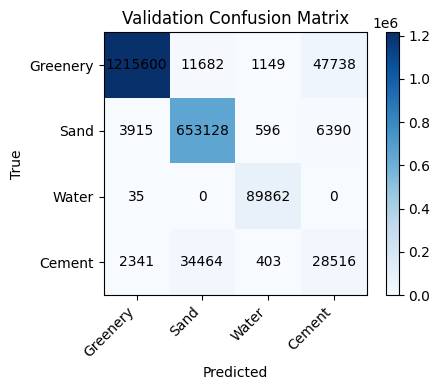

===== Test =====
              precision    recall  f1-score   support

           1     0.9825    0.9628    0.9725   1749576
           2     0.9564    0.9405    0.9484    363768
           3     0.8572    0.9967    0.9217     15210
           4     0.3253    0.6376    0.4308     40327

    accuracy                         0.9532   2168881
   macro avg     0.7803    0.8844    0.8183   2168881
weighted avg     0.9650    0.9532    0.9580   2168881

Confusion Matrix:
 [[1684409   12949    1923   50295]
 [  18091  342119     534    3024]
 [     34       0   15160      16]
 [  11889    2655      69   25714]]
mIoU: 0.7444044417178871
Per-class IoU: {'Greenery': 0.9465152085592748, 'Sand': 0.9018035068481596, 'Water': 0.8547586829048264, 'Cement': 0.27454036855928765}


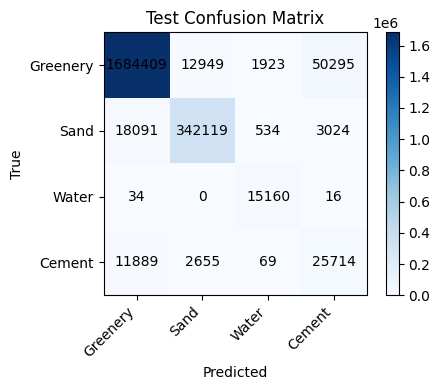

,feature,importance
21,swir1_mean_3,0.185399
17,red_mean_3,0.173385
12,ndvi,0.108919
10,B11,0.076569
18,red_std_3,0.075485
14,mndwi,0.061143
13,ndwi,0.052230
23,swir2_mean_3,0.046934
16,bsi,0.033079
4,B5,0.026011


In [7]:
evaluate_split('Validation', model, X_val, y_val)
evaluate_split('Test', model, X_test, y_test)

importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))


## Notes

- If cement is still weak, improve the split first before adding feature hacks.
- If runtime is high, reduce `TRAIN_CAP_PER_CLASS` to `100_000`.
- If you want a stronger next baseline, the safest follow-up is patch-based CNN training with the same stratified image split.
